# Embedding filters 3 — von Mises-Fisher (directional)

ReID embeddings are compared by cosine similarity, so they really
live on the unit **sphere**, not in flat space — a Euclidean Kalman
filter is the wrong geometry. The von Mises-Fisher distribution is
the sphere's Gaussian: a mean direction `mu` (unit) and a
concentration `kappa` (certainty). Its mean direction has a conjugate
vMF prior, so fusing an observation is an exact, closed-form update —
the resultant of the concentration-weighted directions.

`vmf_state_entries` wires this up: match on `mu` with the ordinary
`Cosine` cost, and read `kappa` as a live confidence.


In [1]:
import torch
import matplotlib.pyplot as plt

import unitrack
from unitrack.assignment import Associate, Jonker
from unitrack.costs import Cosine
from unitrack.data import Detections, FrameContext, TensorSpec
from unitrack.lifecycle import IncludeAll, NoLifecycle
from unitrack.pipeline import Pipe

torch.manual_seed(0)

D = 16          # embedding dimensionality (256+ in practice; 16 plots fast)
T = 44          # frames

def make_clip(noise=0.15, seed=0, switch=None):
    """
    A unit embedding that rotates slowly in the (e0, e1) plane plus
    per-frame noise in all D dims. Rotating in a known plane means
    projecting onto dims (0, 1) shows the true path as a circle arc.
    `switch` optionally rotates the plane mid-clip (an appearance change).
    """
    g = torch.Generator().manual_seed(seed)
    t = torch.arange(T).float()
    theta = 0.10 * t
    truth = torch.zeros(T, D)
    truth[:, 0] = torch.cos(theta)
    truth[:, 1] = torch.sin(theta)
    if switch is not None:
        # after `switch`, swap appearance into the (e2, e3) plane.
        truth[switch:, :] = 0.0
        truth[switch:, 2] = torch.cos(theta[switch:])
        truth[switch:, 3] = torch.sin(theta[switch:])
    obs = truth + noise * torch.randn(T, D, generator=g)
    obs = torch.nn.functional.normalize(obs, dim=-1)
    dets = [Detections(index=torch.tensor([0]), emb=obs[k:k + 1].clone(),
                       batch_size=[1]) for k in range(T)]
    return t, truth, obs, dets

def run(tracker, dets, fields=("emb",)):
    """Run a single-object clip through a real Tracker; collect snapshot fields."""
    ms = unitrack.MultiStream(tracker)
    rec = {f: [] for f in fields}
    for k, d in enumerate(dets):
        ctx = FrameContext.make(frame_idx=k, delta=1.0, fps=1.0, stream_key=0)
        res = ms.step(stream_key=0, detections=d, ctx=ctx)
        for f in fields:
            rec[f].append(getattr(res.snapshot, f)[0].clone())
    return {f: torch.stack(v) for f, v in rec.items()}

def cos_to_truth(est, truth):
    e = torch.nn.functional.normalize(est, dim=-1)
    u = torch.nn.functional.normalize(truth, dim=-1)
    return (e * u).sum(-1)

t, truth, obs, dets = make_clip()
print(f"clip: {T} frames, D={D}; raw-detection mean cosine-to-truth "
      f"= {cos_to_truth(obs, truth).mean():.3f}")


clip: 44 frames, D=16; raw-detection mean cosine-to-truth = 0.855


In [2]:
from unitrack.states import vmf_state_entries

tracker = unitrack.Tracker(
    root=Pipe(cost=Cosine("emb"), assoc=Associate(Jonker(threshold=0.6))),
    states=vmf_state_entries("emb", dim=D, init_kappa=5.0,
                             kappa_obs=12.0, tau=8.0),
    lifecycle=NoLifecycle(), visibility=IncludeAll(),
)
rec = run(tracker, dets, fields=("emb", "emb_kappa"))


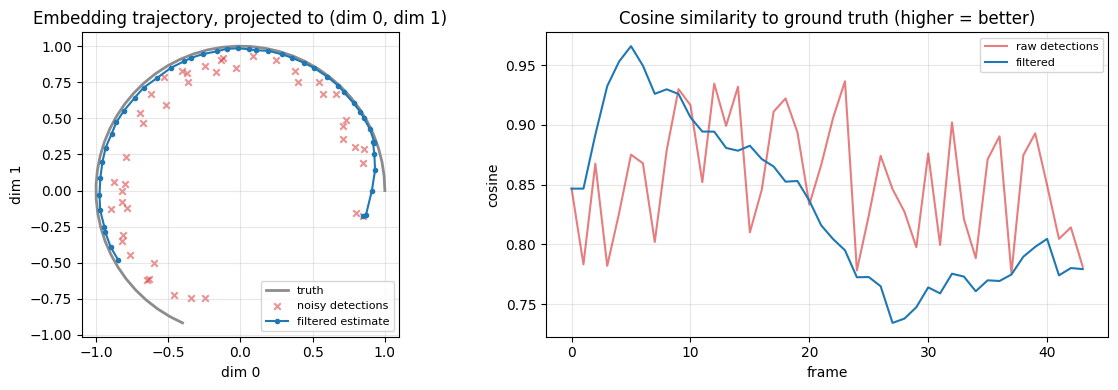

raw mean cos = 0.855   filtered mean cos = 0.832


In [3]:
fig, (axp, axc) = plt.subplots(1, 2, figsize=(12, 4))
axp.plot(truth[:, 0], truth[:, 1], "-", color="0.55", lw=2, label="truth")
axp.scatter(obs[:, 0], obs[:, 1], marker="x", color="tab:red", s=22,
            alpha=0.5, label="noisy detections")
axp.plot(rec["emb"][:, 0], rec["emb"][:, 1], "o-", color="tab:blue",
         ms=3, label="filtered estimate")
axp.set_title("Embedding trajectory, projected to (dim 0, dim 1)")
axp.set_xlabel("dim 0"); axp.set_ylabel("dim 1")
axp.legend(fontsize=8); axp.grid(alpha=0.3); axp.set_aspect("equal")

axc.plot(t, cos_to_truth(obs, truth), color="tab:red", alpha=0.6,
         label="raw detections")
axc.plot(t, cos_to_truth(rec["emb"], truth), color="tab:blue",
         label="filtered")
axc.set_title("Cosine similarity to ground truth (higher = better)")
axc.set_xlabel("frame"); axc.set_ylabel("cosine"); axc.legend(fontsize=8)
axc.grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"raw mean cos = {cos_to_truth(obs, truth).mean():.3f}   "
      f"filtered mean cos = {cos_to_truth(rec['emb'], truth).mean():.3f}")


## Concentration = confidence

The update sharpens the belief (kappa grows) as consistent
detections accumulate; the predict step lets it decay, so a track
that stops being seen becomes *less* certain of its appearance — a
principled, geometry-aware confidence you can feed to a gate.


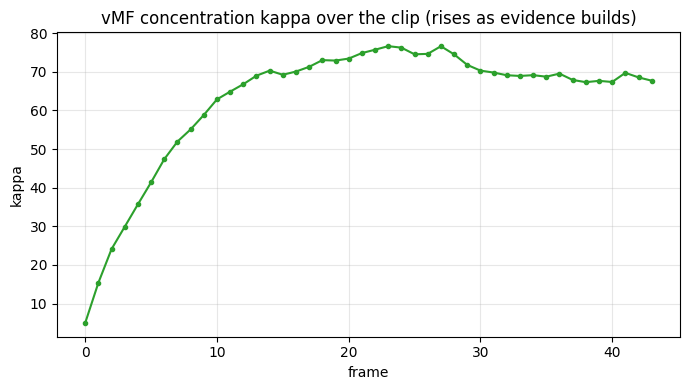

mu stays unit: max |‖mu‖ - 1| = 1.19e-07


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, rec["emb_kappa"], "o-", color="tab:green", ms=3)
ax.set_title("vMF concentration kappa over the clip (rises as evidence builds)")
ax.set_xlabel("frame"); ax.set_ylabel("kappa")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"mu stays unit: max |‖mu‖ - 1| = "
      f"{(rec['emb'].norm(dim=-1) - 1).abs().max():.2e}")


**Takeaway.** vMF is the *right* filter for normalised embeddings:
the estimate provably stays on the sphere and `kappa` is an honest
directional confidence. It is the directional analogue of the Kalman
filter in notebook 2.
